#Load Libraries

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler



#Load Dataset

In [83]:
df = pd.read_csv('/content/drive/MyDrive/ict_aiml/datasets/House_Pricing.csv')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [84]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [85]:
df.shape

(21613, 21)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [87]:
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [88]:
df['Date House was Sold'] = pd.to_datetime(
    df['Date House was Sold']
)

In [89]:
df['Date House was Sold'].dtype

dtype('<M8[ns]')

In [90]:
df['No of Bathrooms'] = pd.to_numeric(df['No of Bathrooms'])

In [91]:
df['No of Bathrooms'].dtype

dtype('float64')

In [92]:
df.describe()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,2017-03-05 23:14:37.638458112,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
min,1.000102e+06,2016-01-15 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2016-04-15 00:00:00,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2017-06-14 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2017-09-14 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2017-12-14 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631


#Check Duplicates

In [93]:
#check for duplicate rows
df.duplicated().sum()


np.int64(0)

In [94]:
#check for duplicate cols
df.T.duplicated().sum()

np.int64(0)

#Handling Missing Values

In [95]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [96]:
df.isna().sum()/len(df)*100

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [97]:
df.dropna(subset=['Living Area after Renovation (in Sqft)',
                  'Longitude',
                  'Latitude',
                  'Zipcode',
                  'Area of the House from Basement (in Sqft)',
                  'Lot Area (in Sqft)',
                  'Flat Area (in Sqft)',
                  'No of Bathrooms',
                  'Sale Price'], inplace = True)

In [98]:
print("After:", df.shape)

After: (21580, 21)


In [99]:
df = df.drop('No of Times Visited', axis=1)

In [100]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


###So no imputation needed

#Encoding

In [101]:
#drop ID column
df = df.drop('ID', axis=1)


In [102]:
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['Waterfront View', 'Condition of the House'], dtype='object')

In [103]:
numerical_columns = df.select_dtypes(include='number').columns
numerical_columns

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [104]:
for col in categorical_columns:
    print(col, ":", df[col].nunique())

Waterfront View : 2
Condition of the House : 5


In [105]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Waterfront View:
['No' 'Yes']

Condition of the House:
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [106]:
#label encoding
le = LabelEncoder()

df['Waterfront View'] = le.fit_transform(df['Waterfront View'])
condition_mapping = {
    'Bad': 0,
    'Okay': 1,
    'Fair': 2,
    'Good': 3,
    'Excellent': 4
}

df['Condition of the House'] = df['Condition of the House'].map(condition_mapping)



In [107]:
df[['Waterfront View', 'Condition of the House']].head()

,Waterfront View,Condition of the House
0,0,2
1,0,2
2,0,2
3,0,4
4,0,2


In [108]:
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,0,4,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


#Outlier Removal

In [115]:
num_outliers = df.drop(columns=['Sale Price']).select_dtypes(include='number').columns

In [117]:
num_outliers

Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Waterfront View',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

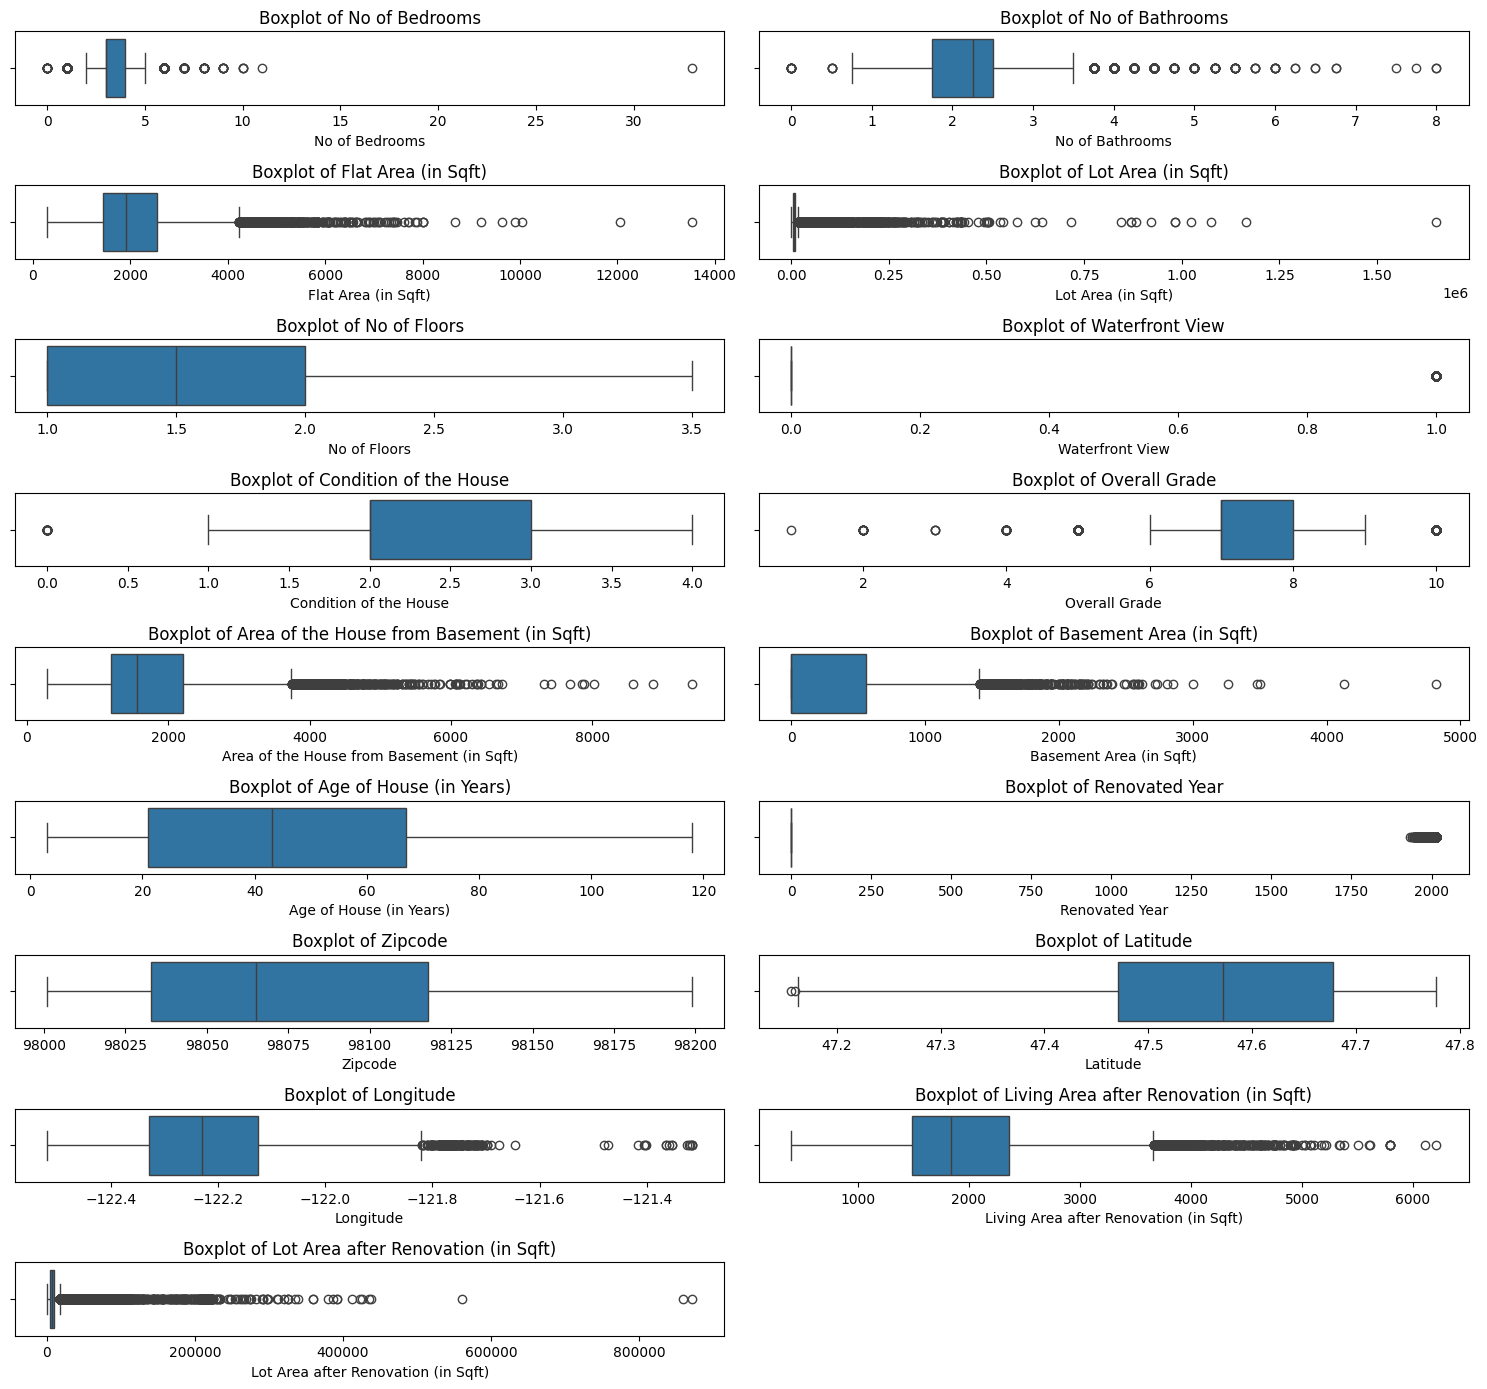

In [116]:
plt.figure(figsize=(15, 14))
n=len(num_outliers)+1
for i, col in enumerate(num_outliers):
    plt.subplot(n//2,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [112]:
df.head(10)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,0,4,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
5,2017-05-14,1230000.0,4,4.50,5420.0,101930.0,1.0,0,2,10,3890.0,1530,17,0,98053.0,47.6561,-122.005,4760.0,101930
6,2017-06-14,257500.0,3,2.25,1715.0,6819.0,2.0,0,2,7,1715.0,0,23,0,98003.0,47.3097,-122.327,2238.0,6819
7,2016-01-15,291850.0,3,1.50,1060.0,9711.0,1.0,0,2,7,1060.0,0,55,0,98198.0,47.4095,-122.315,1650.0,9711
8,2016-04-15,229500.0,3,1.00,1780.0,7470.0,1.0,0,2,7,1050.0,730,58,0,98146.0,47.5123,-122.337,1780.0,8113
9,2016-03-15,323000.0,3,2.50,1890.0,6560.0,2.0,0,2,7,1890.0,0,15,0,98038.0,47.3684,-122.031,2390.0,7570


In [113]:
for col in num_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

No of Bedrooms: 545 outliers
No of Bathrooms: 569 outliers
Flat Area (in Sqft): 571 outliers
Lot Area (in Sqft): 2422 outliers
No of Floors: 0 outliers
Waterfront View: 163 outliers
Condition of the House: 30 outliers
Overall Grade: 1909 outliers
Area of the House from Basement (in Sqft): 610 outliers
Basement Area (in Sqft): 495 outliers
Age of House (in Years): 0 outliers
Renovated Year: 911 outliers
Zipcode: 0 outliers
Latitude: 2 outliers
Longitude: 256 outliers
Living Area after Renovation (in Sqft): 544 outliers
Lot Area after Renovation (in Sqft): 2190 outliers


In [119]:
outlier_cols = [
    'No of Bedrooms',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Age of House (in Years)',
    'Living Area after Renovation (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

In [121]:
def handle_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound,upper=upper_bound)


for col in outlier_cols:
    handle_outliers(col)

df.describe()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,21580,2.158000e+04,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000,21580.000000
mean,2017-03-05 23:38:58.832252160,5.401245e+05,3.363184,2.098338,2057.994347,8707.193594,1.494231,0.007553,2.409361,7.623262,1769.613809,284.025765,47.003290,84.254588,98077.925394,47.559986,-122.213850,1975.021640,8300.928499
min,2016-01-15 00:00:00,7.500000e+04,1.500000,0.625000,290.000000,520.000000,1.000000,0.000000,0.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2016-04-15 00:00:00,3.210202e+05,3.000000,1.750000,1430.000000,5042.750000,1.000000,0.000000,2.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470775,-122.328000,1490.000000,5100.000000
50%,2017-06-14 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7620.000000,1.500000,0.000000,2.000000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571700,-122.230000,1840.000000,7620.000000
75%,2017-09-14 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,10690.500000,2.000000,0.000000,3.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.677900,-122.125000,2360.000000,10087.000000
max,2017-12-14 00:00:00,7.700000e+06,5.500000,3.625000,4230.000000,19162.125000,3.500000,1.000000,4.000000,10.000000,3740.000000,1400.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,3665.000000,17567.500000
std,NaN,3.674325e+05,0.854078,0.722046,838.908213,5046.596335,0.539897,0.086583,0.650733,1.105684,763.928923,417.051120,29.366011,401.344975,53.513818,0.138572,0.140849,649.054181,4365.140623


#Feature Selection

###Correlation Matrix

In [124]:
corr = df.corr(numeric_only=True)

In [125]:
saleprice_corr = corr['Sale Price'].sort_values(ascending=False)

print(saleprice_corr)

Sale Price                                   1.000000
Flat Area (in Sqft)                          0.646660
Overall Grade                                0.580509
Living Area after Renovation (in Sqft)       0.568690
Area of the House from Basement (in Sqft)    0.559102
No of Bathrooms                              0.480812
No of Bedrooms                               0.318190
Latitude                                     0.306846
Basement Area (in Sqft)                      0.289620
Waterfront View                              0.266498
No of Floors                                 0.257121
Lot Area (in Sqft)                           0.195653
Lot Area after Renovation (in Sqft)          0.190581
Renovated Year                               0.126665
Condition of the House                       0.035991
Longitude                                    0.021493
Zipcode                                     -0.053282
Age of House (in Years)                     -0.054066
Name: Sale Price, dtype: flo

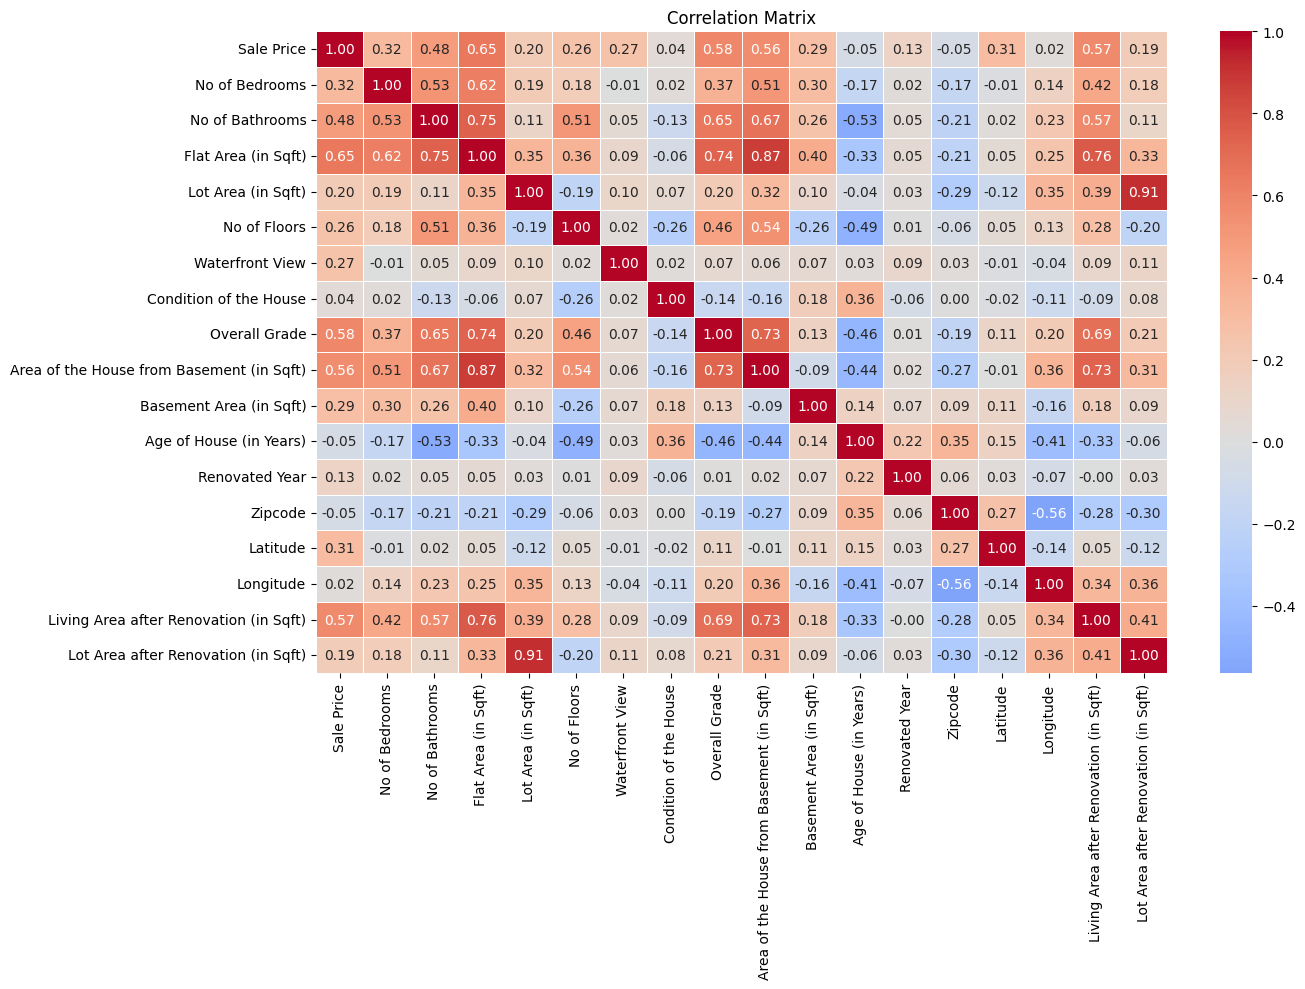

In [129]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [131]:
print(df.select_dtypes(include='number').corr()['Sale Price'].loc[lambda x:x>0.3])

Sale Price                                   1.000000
No of Bedrooms                               0.318190
No of Bathrooms                              0.480812
Flat Area (in Sqft)                          0.646660
Overall Grade                                0.580509
Area of the House from Basement (in Sqft)    0.559102
Latitude                                     0.306846
Living Area after Renovation (in Sqft)       0.568690
Name: Sale Price, dtype: float64


In [134]:
sel_features = ['No of Bedrooms',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Overall Grade',
    'Area of the House from Basement (in Sqft)',
    'Latitude',
    'Living Area after Renovation (in Sqft)'
]

#Train Test Split

In [139]:
X = df[sel_features]
y = df['Sale Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17264, 7)
X_test: (4316, 7)
y_train: (17264,)
y_test: (4316,)


#Scaling



In [140]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)